# Weather Data Analysis & Rainfall Prediction for Groundwater Management in Tank/Well/Pond/Dam

### Objective - 
Comprehensive EDA, preprocessing, feature engineering, and model training to predict rainfall amounts.
Estimating groundwater levels based on weather conditions and deciding optimal pump timing/speed for well/dam management.

**Things to do :**
1. Data Loading & Exploration - weather data [rainfall, sun, evaporation, humidity, etc] & tank water level data
2. EDA (distributions, correlations, missing values)
3. Feature Engineering (rolling sums, pressure changes, temporal features)
4. Preprocessing (imputation, outlier detection [isolation forest] )
5. Model Training & Evaluation - *not done currently*
6. Results & Feature Importance - *not done currently*

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from xgb import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

Parsing data from txt to csv format, and fixing column names

In [2]:
# Configuration & Column Names
column_names = [
    'Date', 'Time', 'Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt',
    'Wind_Speed', 'Wind_Dir', 'Wind_Run', 'Hi_Speed', 'Hi_Dir', 'Wind_Chill',
    'Heat_Index', 'THW_Index', 'THSW_Index', 'Bar', 'Rain', 'Rain_Rate',
    'Solar_Rad', 'Solar_Energy', 'Hi_Rad', 'Solar_Index', 'UV_Dose', 'UV-UV', 
    'Hi_D-D', 'Heat_D-D', 'Cool_Temp', 'In_Hum', 'In_Dew',
    'In_Heat', 'In_EMC', 'In_Density', 'In_ET', 'Air_Samp', 'Wind_Tx',
    'Wind_Recept', 'ISS_Int', 'Arc'
]
DATA_PATH = 'abhishek data.txt'
OUT_CSV = 'weather_processed.csv'

In [3]:
df = pd.read_csv(DATA_PATH, delim_whitespace=True, skiprows=2, names=column_names, na_values=['---', ''])
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (46668, 39)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46668 entries, 0 to 46667
Data columns (total 39 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          46668 non-null  object 
 1   Time          46668 non-null  object 
 2   Temp_Out      46668 non-null  float64
 3   Hi_Temp       46668 non-null  float64
 4   Low_Temp      46668 non-null  float64
 5   Out_Hum       46668 non-null  int64  
 6   Dew_Pt        46668 non-null  float64
 7   Wind_Speed    46668 non-null  float64
 8   Wind_Dir      44299 non-null  object 
 9   Wind_Run      46668 non-null  float64
 10  Hi_Speed      46668 non-null  float64
 11  Hi_Dir        44299 non-null  object 
 12  Wind_Chill    46668 non-null  float64
 13  Heat_Index    46668 non-null  float64
 14  THW_Index     46668 non-null  float64
 15  THSW_Index    46668 non-null  float64
 16  Bar           46668 non-null  float64
 17  Rain          46668 non-null  float64
 18  Rain_Rate     46668 non-nu

In [5]:
df.iloc[:, :20].sample(6)

,Date,Time,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt,Wind_Speed,Wind_Dir,Wind_Run,Hi_Speed,Hi_Dir,Wind_Chill,Heat_Index,THW_Index,THSW_Index,Bar,Rain,Rain_Rate,Solar_Rad
30461,20-06-25,18:45,32.7,33.1,32.4,74,27.5,3.2,NNE,0.80,14.5,NW,32.7,44.5,44.5,44.3,29.703,0.0,0.0,7
5930,11-06-25,12:15,33.7,33.8,33.6,65,26.2,16.1,NE,4.02,24.1,ENE,33.7,43.6,43.6,49.1,29.620,0.0,0.0,594
16400,23-10-25,22:15,26.7,26.7,26.6,94,25.6,3.2,SE,0.80,11.3,ESE,26.7,31.0,31.0,30.4,29.888,1.0,37.8,0
24264,17-04-25,5:30,27.0,27.1,26.9,90,25.2,0.0,WNW,0.00,4.8,WNW,27.0,31.2,31.2,30.4,29.840,0.0,0.0,0
2862,10-05-25,13:15,36.7,37.1,36.5,58,27.1,3.2,NW,0.80,17.7,NW,36.7,50.3,50.3,53.4,29.781,0.0,0.0,241
42583,19-11-25,11:00,27.7,27.8,27.6,87,25.3,8.0,ESE,2.01,17.7,SSE,27.7,32.5,32.5,39.3,29.990,0.0,0.0,781


In [6]:
df.iloc[:, 20:39].head()

,Solar_Energy,Hi_Rad,Solar_Index,UV_Dose,UV-UV,Hi_D-D,Heat_D-D,Cool_Temp,In_Hum,In_Dew,In_Heat,In_EMC,In_Density,In_ET,Air_Samp,Wind_Tx,Wind_Recept,ISS_Int,Arc
0,0.0,0,0.0,0.0,0.0,0.0,0.059,27.4,74,22.4,30.0,13.92,0.0713,0.0,200,1,87.7,10,NaN
1,0.0,0,0.0,0.0,0.0,0.0,0.061,28.1,71,22.3,30.9,12.95,0.0712,0.0,210,1,92.1,10,NaN
2,0.0,0,0.0,0.0,0.0,0.0,0.062,28.0,72,22.5,30.9,13.25,0.0712,0.0,235,1,100.0,10,NaN
3,0.0,0,0.0,0.0,0.0,0.0,0.063,28.1,72,22.6,31.2,13.25,0.0711,0.0,234,1,100.0,10,NaN
4,0.0,0,0.0,0.0,0.0,0.0,0.064,28.3,72,22.7,31.6,13.25,0.0711,0.0,234,1,100.0,10,NaN


### meaning and signficance of all above feature abbreviations

1. THW Index, THSW Index - Temperature-Humidity-Wind, Temperature-Humidity-solar-Wind indexes

2. EMC - Equilibrium Moisture Content
    > *Affects atmospheric moisture and humidity*

3. ET - Evapotranspiration 
    > [*affects water cycle*]

4. Dew UV, Dew Pt. Dose - Dew point measurements 
    > [*when air reaches dew point, condensation occurs*]

5. Solar Rad, Solar_Index, hi_Rad, Solar_Energy - Solar radiation measurements (likely W/m²)

6. Bar Rad., Temp Rad. - Barometric and radiant temperature 
    > [*High-Falling pressure often precedes rain*]



In [7]:
print("Statistical Summary:")
display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Temp_Out,46668.0,28.592774,3.535565,20.0000,26.2000,28.2000,30.9000,40.1000
Hi_Temp,46668.0,28.705443,3.571915,20.1000,26.3000,28.3000,31.1000,40.3000
Low_Temp,46668.0,28.481328,3.500615,19.9000,26.1000,28.1000,30.8000,39.9000
Out_Hum,46668.0,79.880175,10.278026,45.0000,73.0000,81.0000,88.0000,98.0000
Dew_Pt,46668.0,24.596447,1.879230,17.8000,23.5000,24.8000,25.9000,30.0000
Wind_Speed,46668.0,5.680237,4.782198,0.0000,1.6000,4.8000,8.0000,37.0000
Wind_Run,46668.0,1.413213,1.189930,0.0000,0.4000,1.2100,2.0100,9.2500
Hi_Speed,46668.0,12.929281,8.265840,0.0000,6.4000,11.3000,17.7000,69.2000
Wind_Chill,46668.0,28.558541,3.555644,20.0000,26.2000,28.2000,30.9000,40.1000
Heat_Index,46668.0,34.094872,6.755493,20.9000,29.1000,33.0000,38.3000,62.2000


In [8]:
print("MISSING VALUES ANALYSIS")
print("-------------------------------------")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
display(missing_df)

MISSING VALUES ANALYSIS
-------------------------------------


,Missing_Count,Percentage
Arc,46668,100.000000
Wind_Dir,2369,5.076284
Hi_Dir,2369,5.076284
Cool_Temp,6,0.012857
In_Dew,6,0.012857
In_Heat,6,0.012857
In_EMC,6,0.012857
In_Density,6,0.012857


In [9]:
print("TARGET VARIABLE: Rain")
print("-------------------------------------")
print(f"Rain - Min: {df['Rain'].min()}, Max: {df['Rain'].max()}, Mean: {df['Rain'].mean():.4f}")
print(f"Rain Rate - Min: {df['Rain_Rate'].min()}, Max: {df['Rain_Rate'].max()}, Mean: {df['Rain_Rate'].mean():.4f}")
print(f"\nRain > 0 count: {(df['Rain'] > 0).sum()} ({(df['Rain'] > 0).sum() / len(df) * 100:.2f}%)")
print(f"Rain == 0 count: {(df['Rain'] == 0).sum()} ({(df['Rain'] == 0).sum() / len(df) * 100:.2f}%)")

TARGET VARIABLE: Rain
-------------------------------------
Rain - Min: 0.0, Max: 16.8, Mean: 0.0499
Rain Rate - Min: 0.0, Max: 1645.8, Mean: 0.6730

Rain > 0 count: 1990 (4.26%)
Rain == 0 count: 44678 (95.74%)


In [10]:
print("HANDLING MISSING VALUES")
print("-------------------------------------")

# arc column - completely missing, useless
print("1. Dropping 'Arc' column (100% missing) all NaN values")
df = df.drop(columns=['Arc'], errors='ignore')

# Wind_Dir and Hi_Dir have close to 5% missing - categorical (wind direction)
# fill with 0 for now (represent no wind) or mode later if needed
print(f"2. Wind_Dir & Hi_Dir: {df['Wind_Dir'].isna().sum()} missing (~5%)")
print("   -> These are direction values; will fill with 'calm' (0) or forward-fill")
df['Wind_Dir'] = df['Wind_Dir'].fillna(0)  # 0 typically means calm/no wind
df['Hi_Dir'] = df['Hi_Dir'].fillna(0)

# 3. indoor sensor data columns (6 missing) - currently i will fill with median
indoor_cols = ['Cool_Temp', 'In_Dew', 'In_Heat', 'In_EMC', 'In_Density']
print(f"3. Indoor sensor columns: 6 missing each (~0.01%)")
for col in indoor_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
print("filled with median values")

# Verify no more missing values in critical columns
print(f"\nRemaining missing values: {df.isna().sum().sum()}")
print(f"Dataset shape after cleanup: {df.shape}")

HANDLING MISSING VALUES
-------------------------------------
1. Dropping 'Arc' column (100% missing) all NaN values
2. Wind_Dir & Hi_Dir: 2369 missing (~5%)
   -> These are direction values; will fill with 'calm' (0) or forward-fill
3. Indoor sensor columns: 6 missing each (~0.01%)
filled with median values

Remaining missing values: 0
Dataset shape after cleanup: (46668, 38)


## SECTION 3: Feature Engineering

Creating time-based features, rolling rainfall sums, pressure change indicators, and other derived features.

In [11]:
# date and time format
print("Sample Date values:", df['Date'].head(3).tolist())
print("Sample Time values:", df['Time'].head(3).tolist())

# create datetime - try multiple formats
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')  # coerce makes missing places, NaT = Not a Time
print(f"NaT after default parsing: {df['datetime'].isna().sum()}")

# fallback if default fail, specific format trial
if df['datetime'].isna().sum() > len(df) * 0.5:
    # Try dd-mm-yyyy format
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M', errors='coerce')
    print(f"NaT after dd-mm-yyyy format: {df['datetime'].isna().sum()}")

# drop rows where datetime couldn't be parsed
valid_dt = df['datetime'].notna().sum()
print(f"Valid datetime rows: {valid_dt}")

if valid_dt > 0:
    df = df.dropna(subset=['datetime'])
    df = df.set_index('datetime')
    df = df.sort_index()
    
    # Interpolation = intelligently filling in missing numeric values using nearby values in time.
    # Instead of guessing randomly or just slapping in an average
    # Now interpolate numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')
    
    # Fill remaining NaN with median
    for col in numeric_cols:
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    
    print(f"\nFinal dataset: {len(df)} rows")
    print(f"DateTime range: {df.index.min()} to {df.index.max()}")
    print(f"Remaining NaN: {df.isna().sum().sum()}")
else:
    print("ERROR: Could not parse any datetime values!")

Sample Date values: ['25-02-25', '25-02-25', '25-02-25']
Sample Time values: ['16:50', '17:10', '17:20']
NaT after default parsing: 0
Valid datetime rows: 46668

Final dataset: 46668 rows
DateTime range: 2025-01-03 00:00:00 to 2026-07-01 09:30:00
Remaining NaN: 0


In [12]:
print("WIND DIRECTION ANALYSIS")
print("-------------------------------------")

# checking the values and data type
print(f"Wind_Dir dtype: {df['Wind_Dir'].dtype}")
print("Wind_Dir sample values:", df['Wind_Dir'].head(10).tolist())
print("Wind_Dir value counts (top 10):")
print(df['Wind_Dir'].value_counts().head(10))

print(f"\nHi_Dir dtype: {df['Hi_Dir'].dtype}")
print("Hi_Dir sample values:", df['Hi_Dir'].head(10).tolist())

sample_vals = df['Wind_Dir'].dropna().head(50).tolist()
is_text = any(isinstance(v, str) and not v.replace('.','').isdigit() for v in sample_vals if v != 0)

WIND DIRECTION ANALYSIS
-------------------------------------
Wind_Dir dtype: object
Wind_Dir sample values: [0, 0, 'NNW', 'NNW', 'NW', 'NW', 'NW', 'NW', 'NW', 'NW']
Wind_Dir value counts (top 10):
Wind_Dir
NW     13474
NE      6801
ENE     5453
WNW     3450
S       2643
0       2369
SE      1808
NNW     1572
SSE     1495
SW      1399
Name: count, dtype: int64

Hi_Dir dtype: object
Hi_Dir sample values: [0, 0, 'N', 'N', 'ENE', 'ENE', 'NNW', 'NNW', 'NW', 'NW']


In [ ]:
# encoding wind directions - convert text to cyclic numeric degree features
print("ENCODING WIND DIRECTION")
print("-------------------------------------")

# Direction to degrees mapping (16-point mapping)
direction_to_degrees = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    0: 0, '0': 0  # Calm/no wind
}

def encode_wind_direction(direction):
    if pd.isna(direction):
        return 0
    return direction_to_degrees.get(str(direction).upper(), 0)

# Convert Wind_Dir to degrees
df['Wind_Dir_Deg'] = df['Wind_Dir'].apply(encode_wind_direction)
df['Hi_Dir_Deg'] = df['Hi_Dir'].apply(encode_wind_direction)

# If you fed degrees straight into a model:
# 0° (North) and 360° (also North) look far apart numerically
# 359° and 1° look very different, even though they’re almost identical in reality

# Create cyclic features (sin/cos) - important because 0° and 360° are the same!
df['Wind_Dir_Sin'] = np.sin(np.radians(df['Wind_Dir_Deg']))
df['Wind_Dir_Cos'] = np.cos(np.radians(df['Wind_Dir_Deg']))
df['Hi_Dir_Sin'] = np.sin(np.radians(df['Hi_Dir_Deg']))
df['Hi_Dir_Cos'] = np.cos(np.radians(df['Hi_Dir_Deg']))

print(f"\nSample encoded values:")-
print(df[['Wind_Dir', 'Wind_Dir_Deg', 'Wind_Dir_Sin', 'Wind_Dir_Cos']].head(10))

# Drop original text columns (can't use strings in model)
df = df.drop(columns=['Wind_Dir', 'Hi_Dir', 'Date', 'Time'], errors='ignore')
print(f"\nDropped text columns. Final shape: {df.shape}")

ENCODING WIND DIRECTION
-------------------------------------

Sample encoded values:
                    Wind_Dir  Wind_Dir_Deg  Wind_Dir_Sin  Wind_Dir_Cos
datetime                                                              
2025-01-03 00:00:00        0           0.0      0.000000      1.000000
2025-01-03 00:00:00        0           0.0      0.000000      1.000000
2025-01-05 00:00:00      NNW         337.5     -0.382683      0.923880
2025-01-05 00:00:00      NNW         337.5     -0.382683      0.923880
2025-01-05 00:15:00       NW         315.0     -0.707107      0.707107
2025-01-05 00:15:00       NW         315.0     -0.707107      0.707107
2025-01-05 00:30:00       NW         315.0     -0.707107      0.707107
2025-01-05 00:30:00       NW         315.0     -0.707107      0.707107
2025-01-05 00:45:00       NW         315.0     -0.707107      0.707107
2025-01-05 00:45:00       NW         315.0     -0.707107      0.707107

Dropped text columns. Final shape: (46668, 40)


## SECTION 4: Preprocessing - feature engineering for hourly, monthly, yearly analysis

In [14]:
# Feature Engineering
print("FEATURE ENGINEERING")
print("-------------------------------------")

# Rolling rain sums
rain_filled = df['Rain'].fillna(0)
df['rain_1h'] = rain_filled.rolling('1H').sum()
df['rain_6h'] = rain_filled.rolling('6H').sum()
df['rain_24h'] = rain_filled.rolling('24H').sum()
df['rain_7d'] = rain_filled.rolling('168H').sum()
df['rain_30d'] = rain_filled.rolling('720H').sum()

# Pressure features
df['bar_diff_1h'] = df['Bar'].diff()
df['bar_diff_3h'] = df['Bar'].diff(3)
df['bar_rolling_6h'] = df['Bar'].rolling(window=6, min_periods=1).mean()

# Temporal features
df['hour'] = df.index.hour
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

# Temperature features
df['temp_range'] = df['Hi_Temp'] - df['Low_Temp']
df['temp_dewpt_diff'] = df['Temp_Out'] - df['Dew_Pt']

# ET proxy
df['ET'] = (df['Solar_Rad'].fillna(0) * 0.001) * df['temp_dewpt_diff'].abs()

# Humidity-pressure interaction
df['humidity_pressure_interaction'] = df['Out_Hum'] * df['Bar']

print("Engineered features created successfully")
print(f"New dataframe shape: {df.shape}")

FEATURE ENGINEERING
-------------------------------------
Engineered features created successfully
New dataframe shape: (46668, 57)


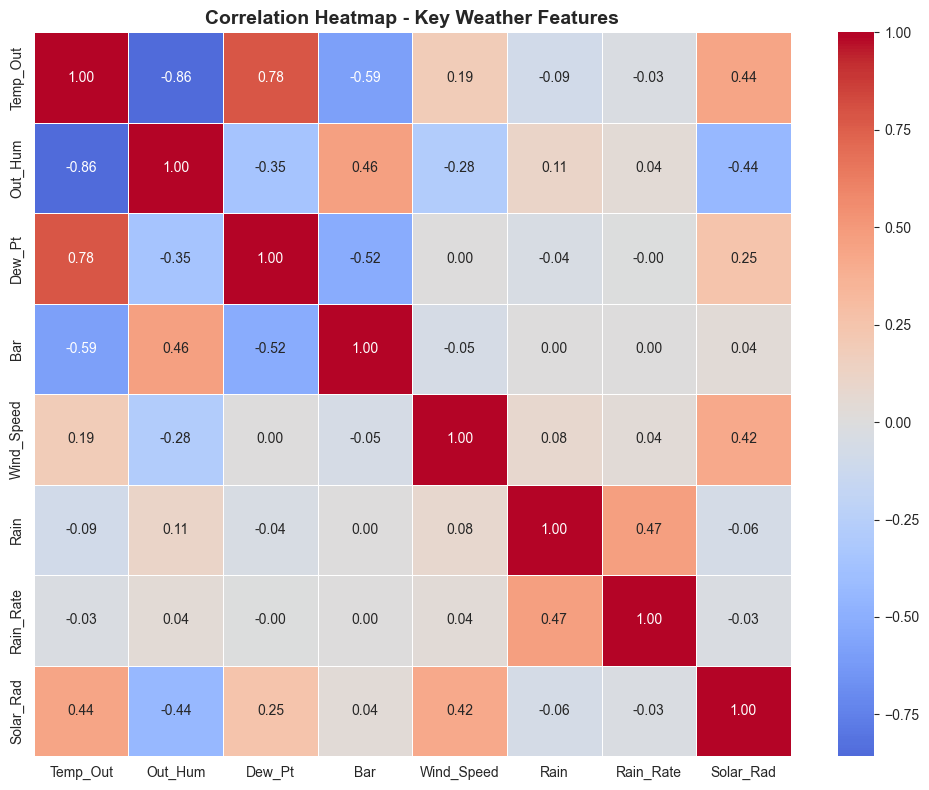

In [15]:
# Correlation Heatmap 
key_features = ['Temp_Out', 'Out_Hum', 'Dew_Pt', 'Bar', 'Wind_Speed', 'Rain', 'Rain_Rate', 'Solar_Rad']
key_features = [f for f in key_features if f in df.columns]
plt.figure(figsize=(10, 8))
sns.heatmap(df[key_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap - Key Weather Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print("CORRELATION WITH RAIN")
print("-------------------------------------")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
rain_corr = corr_matrix['Rain'].sort_values(ascending=False)
print("Top 10 features correlated with Rain:")
display(rain_corr.head(10).to_frame())

CORRELATION WITH RAIN
-------------------------------------
Top 10 features correlated with Rain:


,Rain
Rain,1.000000
rain_1h,0.635510
Rain_Rate,0.471503
rain_6h,0.333963
temp_range,0.200677
rain_24h,0.199151
rain_7d,0.116163
Out_Hum,0.110115
humidity_pressure_interaction,0.108673
Hi_Speed,0.108087


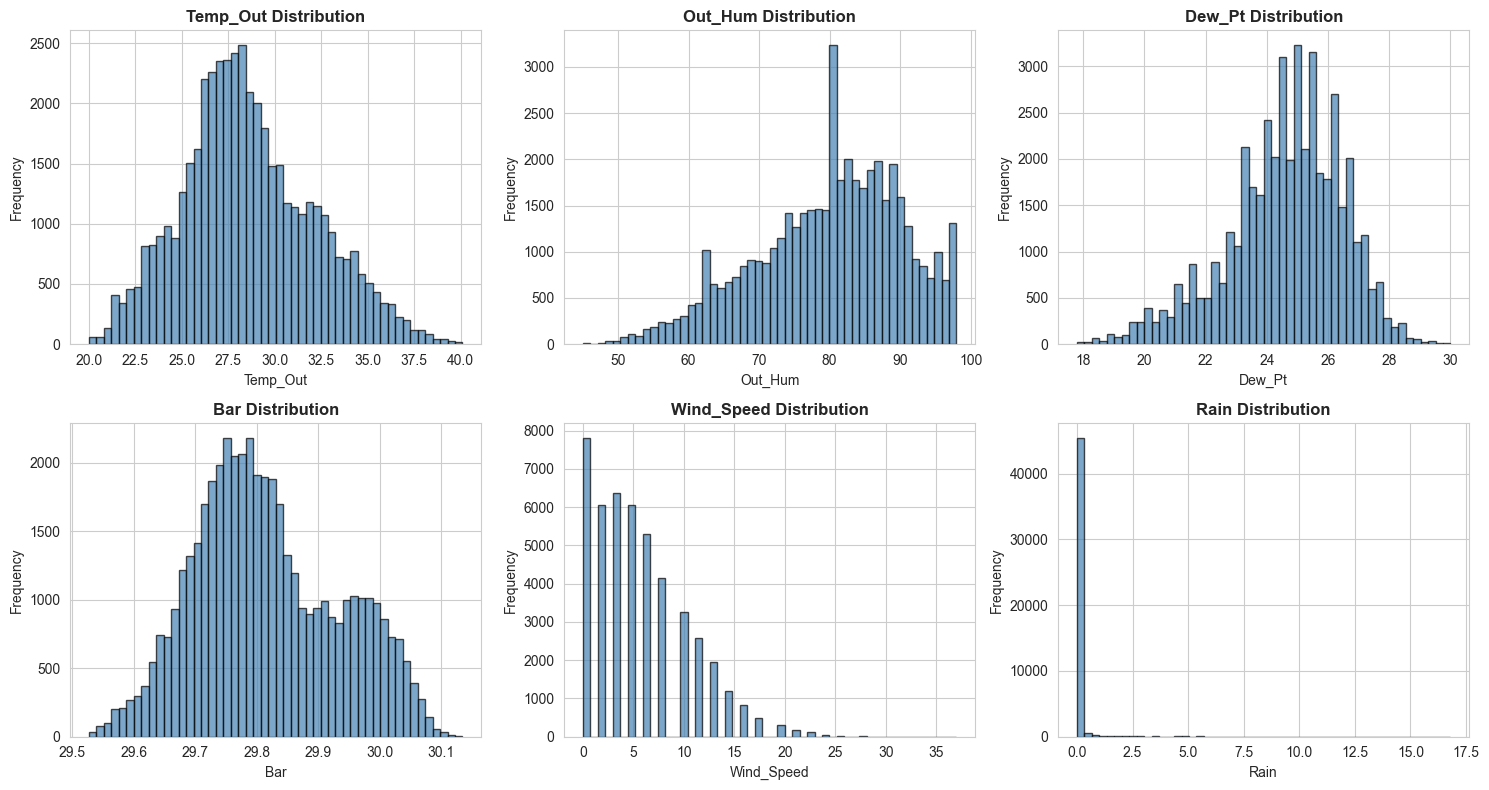

In [17]:
# Distribution Plots of Key Variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
key_cols = ['Temp_Out', 'Out_Hum', 'Dew_Pt', 'Bar', 'Wind_Speed', 'Rain']
for i, col in enumerate(key_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## SECTION 2: Exploratory Data Analysis (EDA)

Let's analyze the target variable (Rain) and understand the distributions, correlations, and patterns in the data.

In [18]:
# Parse datetime & sort
print("DATETIME PARSING")
print("-------------------------------------")

# handle cases where Date/Time columns were already dropped
if 'Date' in df.columns and 'Time' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
    print(f"Failed datetime parses: {df['datetime'].isna().sum()}")
    df = df.sort_values('datetime').reset_index(drop=True)
    df = df.set_index('datetime')
    # Convert numeric columns
    for col in df.columns:
        if col not in ['Date', 'Time']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
else:
    # If already indexed by datetime, just ensure sorting and numeric conversion
    if not isinstance(df.index, pd.DatetimeIndex):
        print("Date/Time columns missing and index is not datetime. Reloading weather data...")
        df = pd.read_csv(DATA_PATH, delim_whitespace=True, skiprows=2, names=column_names, na_values=['---', ''])
        df['datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
        print(f"Failed datetime parses: {df['datetime'].isna().sum()}")
        df = df.sort_values('datetime').reset_index(drop=True)
        df = df.set_index('datetime')
    for col in df.columns:
        if col not in ['Date', 'Time']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"DataFrame after processing: {df.shape}")
display(df.head())

DATETIME PARSING
-------------------------------------
DataFrame after processing: (46668, 57)


,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt,Wind_Speed,Wind_Run,Hi_Speed,Wind_Chill,Heat_Index,...,bar_rolling_6h,hour,month,dayofyear,doy_sin,doy_cos,temp_range,temp_dewpt_diff,ET,humidity_pressure_interaction
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-03 00:00:00,27.6,27.6,27.6,82,24.2,0.0,0.0,0.0,27.6,31.4,...,29.886000,0,1,3,0.051584,0.998669,0.0,3.4,0.0,2450.652
2025-01-03 00:00:00,27.6,27.6,27.6,82,24.2,0.0,0.0,0.0,27.6,31.4,...,29.886000,0,1,3,0.051584,0.998669,0.0,3.4,0.0,2450.652
2025-01-05 00:00:00,29.6,29.7,29.4,79,25.6,3.2,0.8,8.0,29.6,36.0,...,29.860333,0,1,5,0.085906,0.996303,0.3,4.0,0.0,2354.911
2025-01-05 00:00:00,29.6,29.7,29.4,79,25.6,3.2,0.8,8.0,29.6,36.0,...,29.847500,0,1,5,0.085906,0.996303,0.3,4.0,0.0,2354.911
2025-01-05 00:15:00,29.4,29.5,29.3,80,25.6,3.2,0.8,8.0,29.4,35.7,...,29.840400,0,1,5,0.085906,0.996303,0.2,3.8,0.0,2384.960


---

# Part 2: Groundwater Level Analysis & Prediction

## Objective
Merge weather data with groundwater/pond level measurements to:
1. Find correlations between weather features and water levels
2. Predict water levels 4-5 days in advance
3. Create pump control decision system to prevent overflow

In [19]:
# Load Groundwater/Pond Level Data
print("LOADING GROUNDWATER/POND LEVEL DATA")
print("-------------------------------------")

# Load groundwater data
gw_df = pd.read_csv('pool_groundwater_level.csv')
print(f"Groundwater Data Shape: {gw_df.shape}")
print(f"\nColumns: {gw_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(gw_df.head())
print(f"\nBasic Stats:")
display(gw_df.describe())

LOADING GROUNDWATER/POND LEVEL DATA
-------------------------------------
Groundwater Data Shape: (82203, 5)

Columns: ['Serial No.', 'Date', 'Time', 'Device Name', 'tankpercent']

First 5 rows:


,Serial No.,Date,Time,Device Name,tankpercent
0,1,27/01/2026,23:57:29,IIIT Pond,53.0
1,2,27/01/2026,23:52:29,IIIT Pond,53.1
2,3,27/01/2026,23:47:29,IIIT Pond,52.9
3,4,27/01/2026,23:42:29,IIIT Pond,53.0
4,5,27/01/2026,23:37:37,IIIT Pond,52.9



Basic Stats:


,Serial No.,tankpercent
count,82203.000000,82203.000000
mean,41102.000000,46.944003
std,23730.106426,10.325924
min,1.000000,6.800000
25%,20551.500000,43.100000
50%,41102.000000,51.900000
75%,61652.500000,53.000000
max,82203.000000,100.000000


In [20]:
# Parse datetime for groundwater data
gw_df['datetime'] = pd.to_datetime(gw_df['Date'] + ' ' + gw_df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
gw_df = gw_df.sort_values('datetime').reset_index(drop=True)
print(f"Datetime range: {gw_df['datetime'].min()} to {gw_df['datetime'].max()}")
print(f"Total duration: {gw_df['datetime'].max() - gw_df['datetime'].min()}")
print(f"Number of records: {len(gw_df)}")
print(f"\nWater level (tankpercent) stats:")
print(f"  Min: {gw_df['tankpercent'].min():.2f}%")
print(f"  Max: {gw_df['tankpercent'].max():.2f}%")
print(f"  Mean: {gw_df['tankpercent'].mean():.2f}%")
print(f"  Std: {gw_df['tankpercent'].std():.2f}%")

Datetime range: 2025-03-07 18:48:48 to 2026-01-27 23:57:29
Total duration: 326 days 05:08:41
Number of records: 82203

Water level (tankpercent) stats:
  Min: 6.80%
  Max: 100.00%
  Mean: 46.94%
  Std: 10.33%


In [21]:
# Load and prepare weather data
print("LOADING WEATHER DATA")
print("-------------------------------------")

weather_df = pd.read_csv('weather_data.csv')
print(f"Weather Data Shape: {weather_df.shape}")

# Parse datetime for weather data
weather_df['datetime'] = pd.to_datetime(weather_df['Date'] + ' ' + weather_df['Time'], format='%d-%m-%y %H:%M', errors='coerce')
weather_df = weather_df.sort_values('datetime').reset_index(drop=True)
print(f"Weather datetime range: {weather_df['datetime'].min()} to {weather_df['datetime'].max()}")
print(f"\nWeather columns available:")
print(weather_df.columns.tolist())

LOADING WEATHER DATA
-------------------------------------
Weather Data Shape: (46668, 39)
Weather datetime range: 2025-02-25 16:50:00 to 2026-01-07 09:30:00

Weather columns available:
['Date', 'Time', 'Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt', 'Wind_Speed', 'Wind_Dir', 'Wind_Run', 'Hi_Speed', 'Hi_Dir', 'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index', 'Bar', 'Rain', 'Rain_Rate', 'Solar_Rad', 'Solar_Energy', 'Hi_Rad', 'Solar_Index', 'UV_Dose', 'UV-UV', 'Hi_D-D', 'Heat_D-D', 'Cool_Temp', 'In_Hum', 'In_Dew', 'In_Heat', 'In_EMC', 'In_Density', 'In_ET', 'Air_Samp', 'Wind_Tx', 'Wind_Recept', 'ISS_Int', 'Arc', 'datetime']


In [22]:
# HOURLY AGGREGATION - Proper approach for merging misaligned timestamps
print("HOURLY AGGREGATION & MERGING")
print("-------------------------------------")

# Step 1: Create hourly aggregates for GROUNDWATER data
print("\n--- Step 1: Aggregate Groundwater Data (Hourly) ---")
gw_df['hour_bucket'] = gw_df['datetime'].dt.floor('H')  # Round down to hour

# Aggregate: mean of water level for each hour
gw_hourly = gw_df.groupby('hour_bucket').agg({
    'tankpercent': ['mean', 'min', 'max', 'std', 'count']
}).reset_index()

# Flatten column names
gw_hourly.columns = ['datetime', 'water_level_mean', 'water_level_min', 
                     'water_level_max', 'water_level_std', 'gw_readings_count']
print(f"Groundwater hourly records: {len(gw_hourly)}")
print(f"Date range: {gw_hourly['datetime'].min()} to {gw_hourly['datetime'].max()}")

# Step 2: Create hourly aggregates for WEATHER data  
print("\n--- Step 2: Aggregate Weather Data (Hourly) ---")
weather_df['hour_bucket'] = weather_df['datetime'].dt.floor('H')

# Select numeric columns for aggregation
weather_numeric_cols = weather_df.select_dtypes(include=[np.number]).columns.tolist()
weather_numeric_cols = [c for c in weather_numeric_cols if c not in ['Date', 'Time']]

# Aggregate weather data by hour (mean for most, sum for Rain)
weather_agg_dict = {col: 'mean' for col in weather_numeric_cols}
weather_agg_dict['Rain'] = 'sum'  # Total rainfall in the hour
weather_agg_dict['Rain_Rate'] = 'max'  # Peak rain rate

weather_hourly = weather_df.groupby('hour_bucket').agg(weather_agg_dict).reset_index()
weather_hourly = weather_hourly.rename(columns={'hour_bucket': 'datetime'})
print(f"Weather hourly records: {len(weather_hourly)}")
print(f"Date range: {weather_hourly['datetime'].min()} to {weather_hourly['datetime'].max()}")

# Step 3: INNER JOIN - Only keep hours where BOTH datasets have data
print("\n--- Step 3: Merge Datasets (Inner Join on datetime) ---")
merged_df = pd.merge(gw_hourly, weather_hourly, on='datetime', how='inner')
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Date range: {merged_df['datetime'].min()} to {merged_df['datetime'].max()}")
print(f"Total hours with both water level AND weather data: {len(merged_df)}")

# Verify NO NaN values from merge
nan_count = merged_df.isna().sum().sum()
print(f"\nNaN values after merge: {nan_count}")

# Display sample of merged data
print("\nSample of merged hourly data:")
display(merged_df[['datetime', 'water_level_mean', 'Temp_Out', 'Out_Hum', 'Rain', 'Bar']].head(10))

HOURLY AGGREGATION & MERGING
-------------------------------------

--- Step 1: Aggregate Groundwater Data (Hourly) ---
Groundwater hourly records: 7173
Date range: 2025-03-07 18:00:00 to 2026-01-27 23:00:00

--- Step 2: Aggregate Weather Data (Hourly) ---
Weather hourly records: 5861
Date range: 2025-02-25 16:00:00 to 2026-01-07 09:00:00

--- Step 3: Merge Datasets (Inner Join on datetime) ---
Merged dataset shape: (5165, 41)
Date range: 2025-03-18 14:00:00 to 2026-01-07 09:00:00
Total hours with both water level AND weather data: 5165

NaN values after merge: 5224

Sample of merged hourly data:


,datetime,water_level_mean,Temp_Out,Out_Hum,Rain,Bar
0,2025-03-18 14:00:00,44.175000,32.509091,74.318182,0.0,29.844182
1,2025-03-18 15:00:00,44.108333,32.505556,73.888889,0.0,29.839083
2,2025-03-18 16:00:00,44.209091,33.550000,70.750000,5.6,29.841500
3,2025-03-18 17:00:00,45.730000,32.975000,69.250000,0.0,29.850500
4,2025-03-18 18:00:00,44.558333,31.750000,70.000000,0.0,29.870250
5,2025-03-18 19:00:00,44.616667,29.950000,75.000000,0.0,29.893250
6,2025-03-18 20:00:00,44.600000,28.850000,78.500000,0.0,29.921000
7,2025-03-18 21:00:00,44.600000,27.825000,81.250000,0.0,29.949750
8,2025-03-18 22:00:00,44.600000,26.950000,83.250000,0.0,29.967750
9,2025-03-18 23:00:00,44.591667,26.400000,84.000000,0.0,29.968250


In [23]:
# Investigate remaining NaN values after merge
print("INVESTIGATING NaN VALUES IN MERGED DATA")
print("-------------------------------------")

nan_per_column = merged_df.isna().sum()
nan_cols = nan_per_column[nan_per_column > 0].sort_values(ascending=False)
print("\nColumns with NaN values:")
display(nan_cols)

# These NaNs are from weather aggregation where some hourly buckets had no data for certain sensors
print("\nPercentage missing per column:")
for col, count in nan_cols.items():
    pct = count / len(merged_df) * 100
    print(f"  {col}: {count} ({pct:.2f}%)")

INVESTIGATING NaN VALUES IN MERGED DATA
-------------------------------------

Columns with NaN values:


Arc                5165
water_level_std      59
dtype: int64


Percentage missing per column:
  Arc: 5165 (100.00%)
  water_level_std: 59 (1.14%)


In [24]:
# CLEAN UP MERGED DATA
print("CLEANING MERGED DATASET")
print("-------------------------------------")

# 1. Drop 'Arc' column (100% missing)
merged_df = merged_df.drop(columns=['Arc'], errors='ignore')
print("1. Dropped 'Arc' column (100% missing)")

# 2. Fill water_level_std NaN with 0 (means stable reading in that hour)
merged_df['water_level_std'] = merged_df['water_level_std'].fillna(0)
print("2. Filled water_level_std NaN with 0 (single reading = no variance)")

# Final check
print(f"\nFinal merged dataset shape: {merged_df.shape}")
print(f"Total NaN values: {merged_df.isna().sum().sum()}")
print(f"Date range: {merged_df['datetime'].min()} to {merged_df['datetime'].max()}")
print(f"Duration: {merged_df['datetime'].max() - merged_df['datetime'].min()}")
print(f"\nColumns in merged dataset ({len(merged_df.columns)}):")
print(merged_df.columns.tolist())

CLEANING MERGED DATASET
-------------------------------------
1. Dropped 'Arc' column (100% missing)
2. Filled water_level_std NaN with 0 (single reading = no variance)

Final merged dataset shape: (5165, 40)
Total NaN values: 0
Date range: 2025-03-18 14:00:00 to 2026-01-07 09:00:00
Duration: 294 days 19:00:00

Columns in merged dataset (40):
['datetime', 'water_level_mean', 'water_level_min', 'water_level_max', 'water_level_std', 'gw_readings_count', 'Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt', 'Wind_Speed', 'Wind_Run', 'Hi_Speed', 'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index', 'Bar', 'Rain', 'Rain_Rate', 'Solar_Rad', 'Solar_Energy', 'Hi_Rad', 'Solar_Index', 'UV_Dose', 'UV-UV', 'Hi_D-D', 'Heat_D-D', 'Cool_Temp', 'In_Hum', 'In_Dew', 'In_Heat', 'In_EMC', 'In_Density', 'In_ET', 'Air_Samp', 'Wind_Tx', 'Wind_Recept', 'ISS_Int']


In [25]:
# FEATURE IMPORTANCE ANALYSIS - Which features matter most for water level
print("FEATURE IMPORTANCE FOR WATER LEVEL PREDICTION")
print("-------------------------------------")

# Use merged hourly data to compute correlations
if 'merged_df' not in globals():
    raise ValueError("merged_df not found. Run the hourly merge section first.")

# Ensure datetime index for correlation consistency
if 'datetime' in merged_df.columns:
    merged_df = merged_df.set_index('datetime').sort_index()

correlations = merged_df.corr(numeric_only=True)['water_level_mean'].drop('water_level_mean').abs().sort_values(ascending=False)

print("TOP 20 FEATURES BY CORRELATION WITH WATER LEVEL")
print("-------------------------------------")
for i, (feat, corr) in enumerate(correlations.head(20).items(), 1):
    original_corr = merged_df.corr(numeric_only=True)['water_level_mean'][feat]
    direction = "↑" if original_corr > 0 else "↓"
    strength = "STRONG" if corr > 0.3 else "MODERATE" if corr > 0.15 else "WEAK"
    print(f"{i:2}. {feat:25} | r = {original_corr:+.4f} {direction} | {strength}")

FEATURE IMPORTANCE FOR WATER LEVEL PREDICTION
-------------------------------------
TOP 20 FEATURES BY CORRELATION WITH WATER LEVEL
-------------------------------------
 1. water_level_min           | r = +0.9124 ↑ | STRONG
 2. water_level_max           | r = +0.6553 ↑ | STRONG
 3. In_Hum                    | r = +0.4072 ↑ | STRONG
 4. THW_Index                 | r = -0.3941 ↓ | STRONG
 5. Heat_Index                | r = -0.3925 ↓ | STRONG
 6. In_EMC                    | r = +0.3903 ↑ | STRONG
 7. Wind_Chill                | r = -0.3795 ↓ | STRONG
 8. Low_Temp                  | r = -0.3774 ↓ | STRONG
 9. Temp_Out                  | r = -0.3764 ↓ | STRONG
10. Heat_D-D                  | r = -0.3756 ↓ | STRONG
11. Hi_Temp                   | r = -0.3753 ↓ | STRONG
12. Dew_Pt                    | r = -0.3574 ↓ | STRONG
13. In_Dew                    | r = +0.3438 ↑ | STRONG
14. THSW_Index                | r = -0.3164 ↓ | STRONG
15. Bar                       | r = +0.3032 ↑ | STRONG
16. O

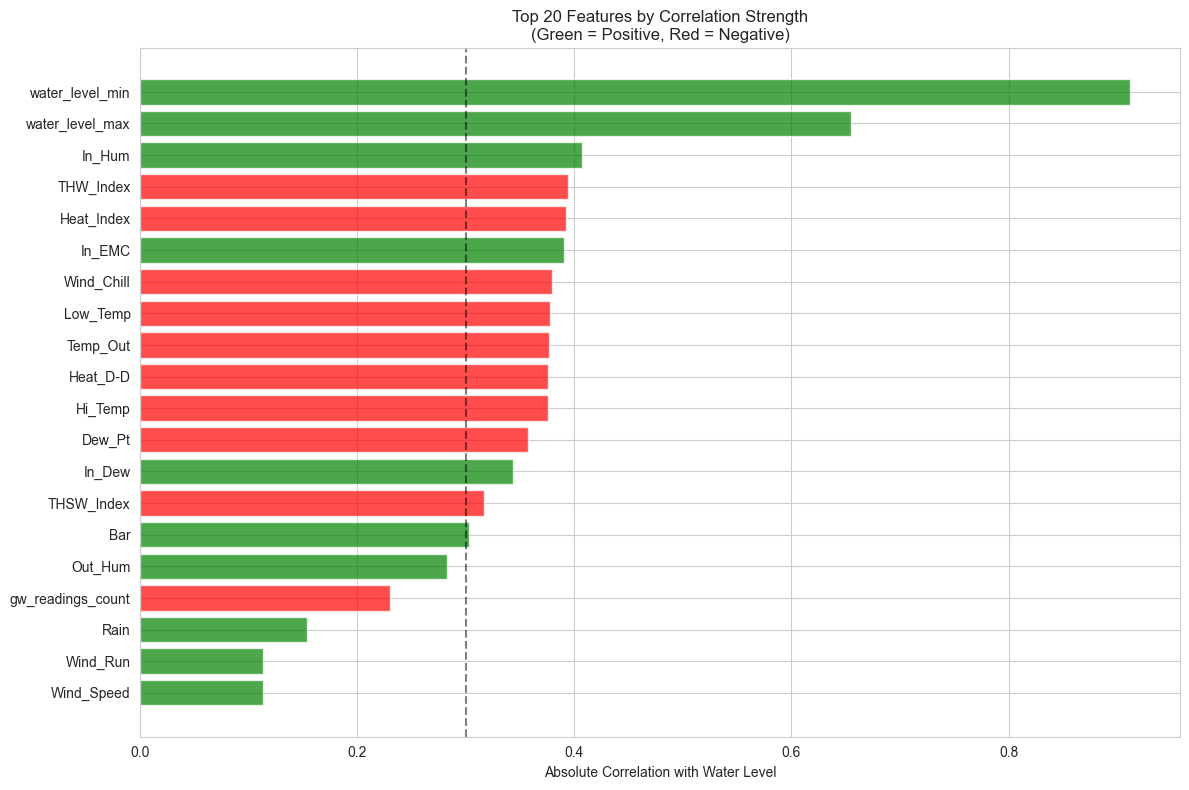

In [26]:
# VISUALIZE FEATURE IMPORTANCE
import matplotlib.pyplot as plt

if 'correlations' not in globals():
    raise ValueError("Run the feature-importance cell after the merge first.")

fig, ax = plt.subplots(figsize=(12, 8))

top_20 = correlations.head(20)
colors = ['green' if merged_df.corr(numeric_only=True)['water_level_mean'][f] > 0 else 'red' for f in top_20.index]

ax.barh(range(len(top_20)), top_20.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.invert_yaxis()
ax.set_xlabel('Absolute Correlation with Water Level')
ax.set_title('Top 20 Features by Correlation Strength\n(Green = Positive, Red = Negative)')
ax.axvline(x=0.3, color='black', linestyle='--', alpha=0.5, label='Strong threshold')

plt.tight_layout()
plt.show()

## SECTION 5: Clean Feature Engineering on Merged Data

**Only creating features that make physical sense for water level prediction:**
- **Autoregressive** (water-level lags): wl_lag_1h, wl_lag_6h, wl_lag_24h + rate-of-change. These are NOT leakage — at prediction time you KNOW the current water level. The old version had 9+ lags which was redundant; 3 key lags capture short/medium/daily memory.
- Temporal: hour (cyclic), month (cyclic), is_daytime — seasonal/diurnal patterns
- Weather rolling: cumulative rain (24h, 72h), avg temperature & humidity (24h) — recent weather trends
- Pressure change (3h, 24h) — pressure drops precede rain
- Evaporation proxy — drives water loss


In [27]:
# FEATURE ENGINEERING ON MERGED DATA
print("FEATURE ENGINEERING ON MERGED DATA")
print("=" * 50)

# Ensure datetime index
if 'datetime' in merged_df.columns:
    merged_df = merged_df.set_index('datetime').sort_index()

# --- 1. Temporal features (cyclic) ---
merged_df['hour'] = merged_df.index.hour
merged_df['month'] = merged_df.index.month
merged_df['is_daytime'] = ((merged_df['hour'] >= 6) & (merged_df['hour'] <= 18)).astype(int)
merged_df['hour_sin'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['hour_cos'] = np.cos(2 * np.pi * merged_df['hour'] / 24)
merged_df['month_sin'] = np.sin(2 * np.pi * merged_df['month'] / 12)
merged_df['month_cos'] = np.cos(2 * np.pi * merged_df['month'] / 12)
print("1. Temporal: hour, month (cyclic), is_daytime")

# --- 2. Cumulative rainfall (the main driver of water level rise) ---
merged_df['rain_sum_24h'] = merged_df['Rain'].rolling(24, min_periods=1).sum()
merged_df['rain_sum_72h'] = merged_df['Rain'].rolling(72, min_periods=1).sum()
print("2. Rainfall: rain_sum_24h, rain_sum_72h")

# --- 3. Temperature & humidity trends (drive evaporation) ---
merged_df['temp_avg_24h'] = merged_df['Temp_Out'].rolling(24, min_periods=1).mean()
merged_df['hum_avg_24h'] = merged_df['Out_Hum'].rolling(24, min_periods=1).mean()
print("3. Weather trends: temp_avg_24h, hum_avg_24h")

# --- 4. Pressure change (dropping pressure -> rain coming) ---
merged_df['bar_change_3h'] = merged_df['Bar'].diff(3)
merged_df['bar_change_24h'] = merged_df['Bar'].diff(24)
print("4. Pressure change: bar_change_3h, bar_change_24h")

# --- 5. Evaporation proxy (higher temp + lower humidity + more wind = more evaporation) ---
merged_df['evap_proxy'] = (merged_df['Temp_Out'] * (100 - merged_df['Out_Hum']) / 100) * (merged_df['Wind_Speed'] + 0.5)
print("5. Evaporation proxy: evap_proxy")

# --- 6. Autoregressive features (critical for time-series prediction) ---
# These are NOT leakage: at prediction time, you KNOW the current/past water levels.
# Only 3 key lags: 1h (persistence), 6h (short trend), 24h (daily cycle)
merged_df['wl_lag_1h'] = merged_df['water_level_mean'].shift(1)
merged_df['wl_lag_6h'] = merged_df['water_level_mean'].shift(6)
merged_df['wl_lag_24h'] = merged_df['water_level_mean'].shift(24)

# Rate-of-change features - all LAGGED by 1h to avoid leaking y[t]
merged_df['wl_change_1h'] = merged_df['water_level_mean'].diff(1).shift(1)
merged_df['wl_change_6h'] = merged_df['water_level_mean'].diff(6).shift(1)
merged_df['wl_change_24h'] = merged_df['water_level_mean'].diff(24).shift(1)
print("6. Autoregressive: wl_lag_1h, wl_lag_6h, wl_lag_24h + lagged change rates")

# --- 7. Operational regime features (pump/overflow behavior) ---
# These help model sudden drops during rainy + humid periods as pump operations, not outliers.
merged_df['wl_drop_event_1h'] = (merged_df['wl_change_1h'] <= -5).astype(int)
merged_df['wl_rise_event_1h'] = (merged_df['wl_change_1h'] >= 3).astype(int)
merged_df['overflow_risk_prev1h'] = ((merged_df['wl_lag_1h'] >= 80) & (merged_df['rain_sum_24h'] > 0)).astype(int)
merged_df['drain_after_rain_flag'] = (
    (merged_df['wl_drop_event_1h'] == 1) &
    (merged_df['rain_sum_24h'] > 0) &
    (merged_df['Out_Hum'] >= 70)
).astype(int)
merged_df['pump_cycle_recent_6h'] = merged_df['wl_drop_event_1h'].rolling(6, min_periods=1).sum()
merged_df['rain_x_humidity'] = merged_df['Rain'] * merged_df['Out_Hum']
merged_df['rain_x_wl_lag1'] = merged_df['Rain'] * merged_df['wl_lag_1h']
print("7. Operational regime: drop/rise events, overflow risk, drain-after-rain, pump-cycle intensity")

# --- Drop columns not useful for modeling ---
drop_cols = [
    # Indoor sensor data (irrelevant)
    'In_Hum', 'In_Dew', 'In_Heat', 'In_EMC', 'In_Density', 'In_ET',
    'Cool_Temp',
    # Sensor metadata
    'Air_Samp', 'Wind_Tx', 'Wind_Recept', 'ISS_Int',
    # Aggregation metadata
    'gw_readings_count', 'water_level_std',
    # Leaky target-adjacent features (min/max are just target with noise)
    'water_level_min', 'water_level_max',
    # Redundant with cyclic versions
    'hour', 'month',
    # UV features with mostly zeros
    'UV_Dose', 'UV-UV', 'Solar_Index',
    # Redundant temperature variants
    'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index',
    'Hi_D-D', 'Heat_D-D',
]
drop_cols = [c for c in drop_cols if c in merged_df.columns]
merged_df = merged_df.drop(columns=drop_cols)

# Fill NaN introduced by rolling/diff (first few rows)
merged_df = merged_df.iloc[24:]  # drop first 24 rows (lag/rolling warmup)
merged_df = merged_df.ffill().bfill()  # handle any remaining edge NaN

print(f"\nDropped {len(drop_cols)} irrelevant/leaky columns")
print(f"Final shape: {merged_df.shape}")
print(f"Features: {len(merged_df.columns) - 1} + 1 target (water_level_mean)")
print(f"Operational drain-after-rain rows retained: {int(merged_df['drain_after_rain_flag'].sum())}")
print(f"\nColumn list:")
for i, col in enumerate(sorted(merged_df.columns), 1):
    tag = "TARGET" if col == 'water_level_mean' else ""
    print(f"  {i:2}. {col:25} {tag}")

FEATURE ENGINEERING ON MERGED DATA
1. Temporal: hour, month (cyclic), is_daytime
2. Rainfall: rain_sum_24h, rain_sum_72h
3. Weather trends: temp_avg_24h, hum_avg_24h
4. Pressure change: bar_change_3h, bar_change_24h
5. Evaporation proxy: evap_proxy
6. Autoregressive: wl_lag_1h, wl_lag_6h, wl_lag_24h + lagged change rates
7. Operational regime: drop/rise events, overflow risk, drain-after-rain, pump-cycle intensity

Dropped 26 irrelevant/leaky columns
Final shape: (5141, 40)
Features: 39 + 1 target (water_level_mean)
Operational drain-after-rain rows retained: 113

Column list:
   1. Bar                       
   2. Dew_Pt                    
   3. Hi_Rad                    
   4. Hi_Speed                  
   5. Hi_Temp                   
   6. Low_Temp                  
   7. Out_Hum                   
   8. Rain                      
   9. Rain_Rate                 
  10. Solar_Energy              
  11. Solar_Rad                 
  12. Temp_Out                  
  13. Wind_Run      

In [28]:
# CORRELATION WITH WATER LEVEL — sanity check
print("FEATURE CORRELATIONS WITH WATER LEVEL")
print("=" * 50)

corr = merged_df.corr(numeric_only=True)['water_level_mean'].drop('water_level_mean')
corr_sorted = corr.abs().sort_values(ascending=False)

for feat in corr_sorted.index:
    r = corr[feat]
    bar = "#" * int(abs(r) * 30)
    print(f"  {feat:25} | r={r:+.3f} | {bar}")

print("\nNOTE: Strong correlations from lag features are expected in autoregressive forecasting.")
print("Leakage is prevented because all lag/change features are shifted to past timestamps only.")

FEATURE CORRELATIONS WITH WATER LEVEL
  wl_lag_1h                 | r=+0.904 | ███████████████████████████
  wl_lag_6h                 | r=+0.758 | ██████████████████████
  wl_lag_24h                | r=+0.718 | █████████████████████
  month_cos                 | r=+0.579 | █████████████████
  temp_avg_24h              | r=-0.548 | ████████████████
  month_sin                 | r=-0.467 | █████████████
  hum_avg_24h               | r=+0.455 | █████████████
  Low_Temp                  | r=-0.378 | ███████████
  Temp_Out                  | r=-0.377 | ███████████
  Hi_Temp                   | r=-0.376 | ███████████
  Dew_Pt                    | r=-0.357 | ██████████
  Bar                       | r=+0.305 | █████████
  Out_Hum                   | r=+0.284 | ████████
  rain_sum_72h              | r=+0.272 | ████████
  wl_change_24h             | r=+0.249 | ███████
  rain_sum_24h              | r=+0.243 | ███████
  wl_change_6h              | r=+0.231 | ██████
  rain_x_wl_lag1            | r

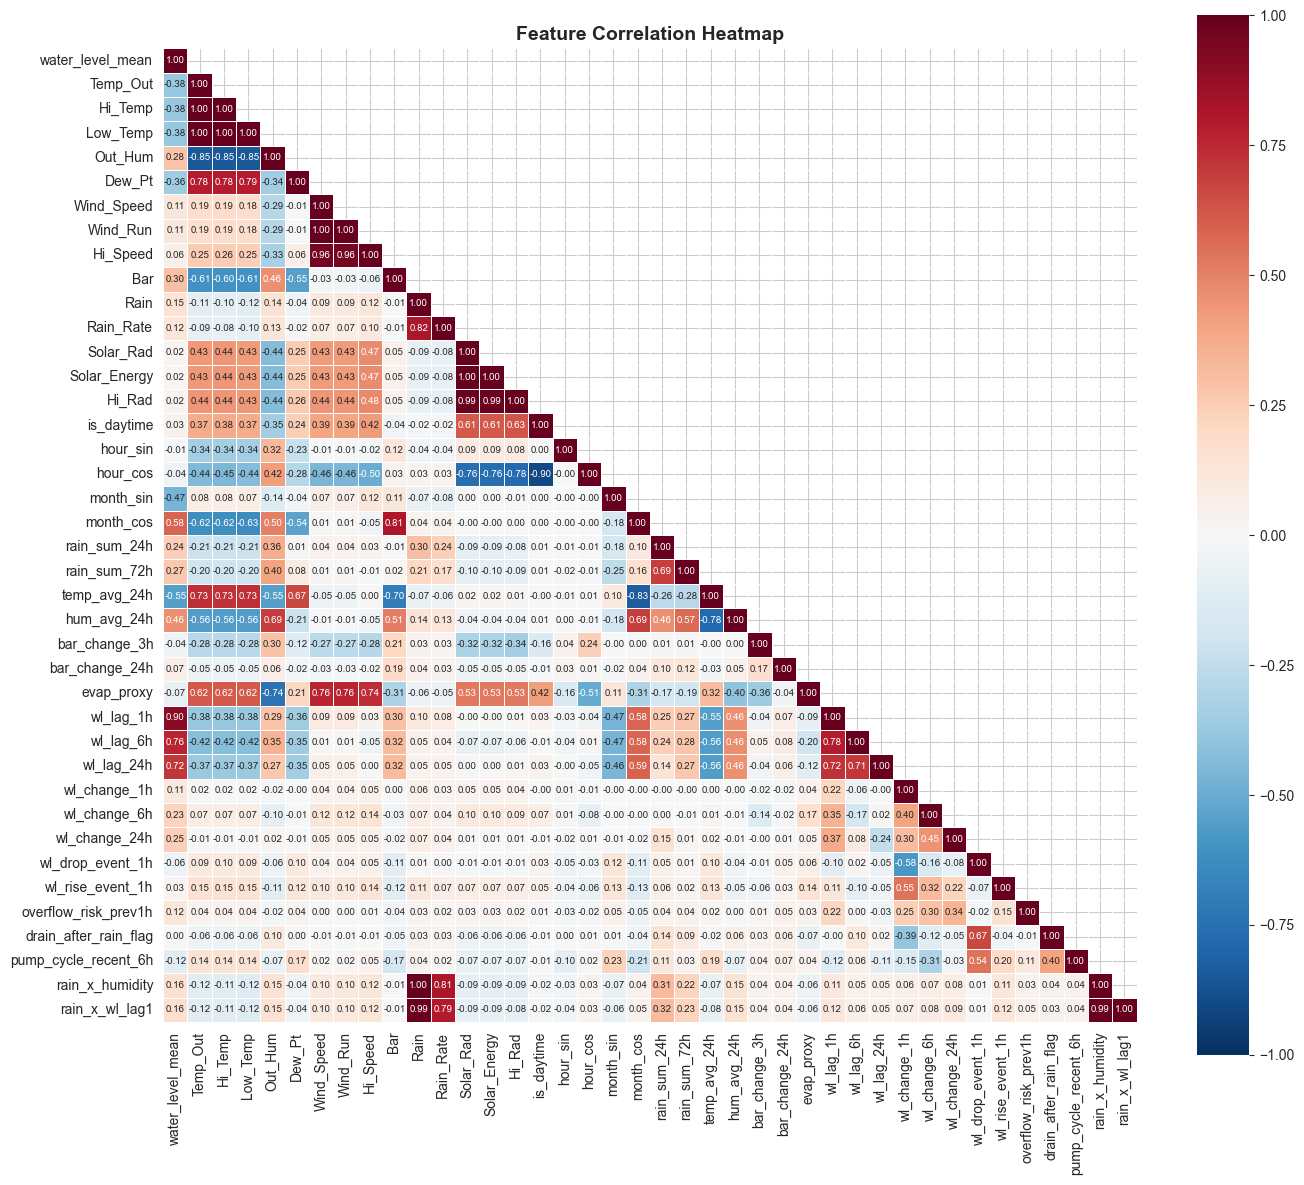

In [29]:
# CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = merged_df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

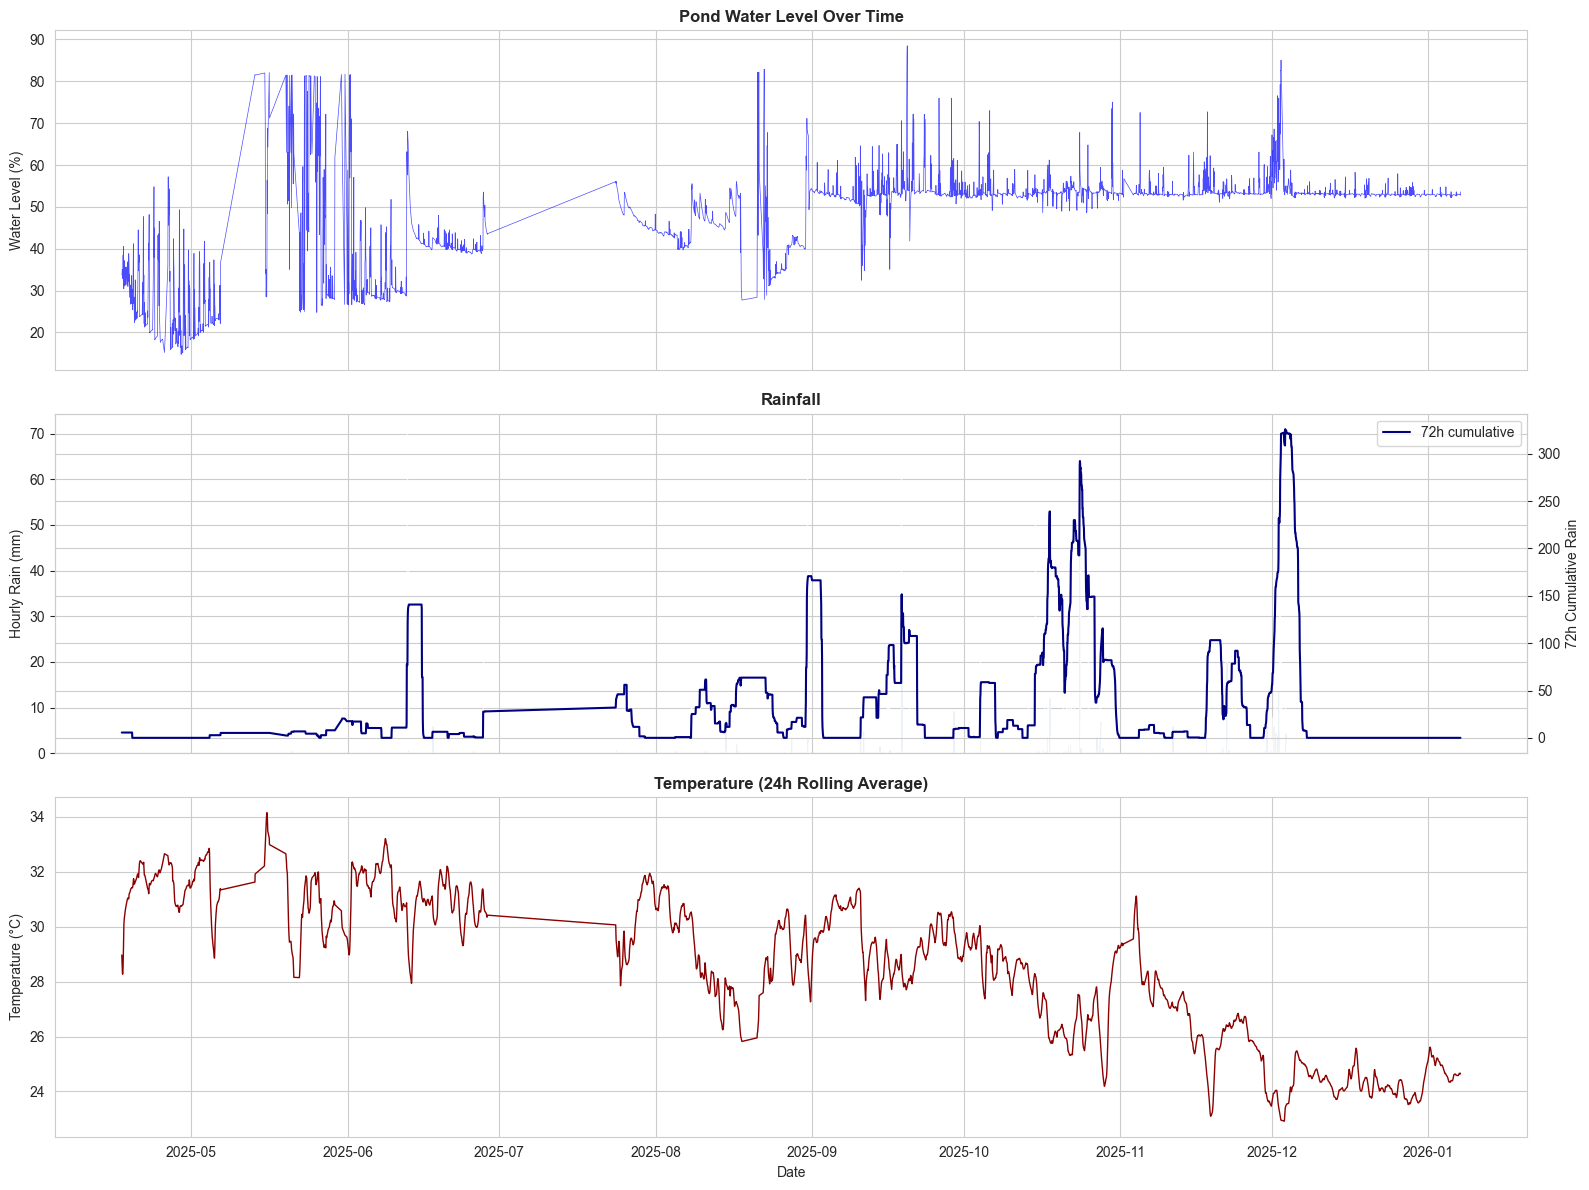

OBSERVATIONS:
  - Rainfall spikes → water level rises (with 1-3 day lag)
  - Sudden water level drops = tank emptying (operational, NOT anomaly)
  - Higher temperatures → gradual water level decline (evaporation)


In [30]:
# TIME SERIES OVERVIEW — Water Level + Key Weather
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 1. Water Level
axes[0].plot(merged_df.index, merged_df['water_level_mean'], color='blue', alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('Water Level (%)')
axes[0].set_title('Pond Water Level Over Time', fontweight='bold')

# 2. Rainfall
axes[1].bar(merged_df.index, merged_df['Rain'], color='steelblue', alpha=0.7, width=0.03)
ax1r = axes[1].twinx()
ax1r.plot(merged_df.index, merged_df['rain_sum_72h'], color='navy', linewidth=1.5, label='72h cumulative')
axes[1].set_ylabel('Hourly Rain (mm)')
ax1r.set_ylabel('72h Cumulative Rain')
axes[1].set_title('Rainfall', fontweight='bold')
ax1r.legend(loc='upper right')

# 3. Temperature
axes[2].plot(merged_df.index, merged_df['temp_avg_24h'], color='darkred', linewidth=1, label='24h avg temp')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_title('Temperature (24h Rolling Average)', fontweight='bold')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

print("OBSERVATIONS:")
print("  - Rainfall spikes → water level rises (with 1-3 day lag)")
print("  - Sudden water level drops = tank emptying (operational, NOT anomaly)")
print("  - Higher temperatures → gradual water level decline (evaporation)")

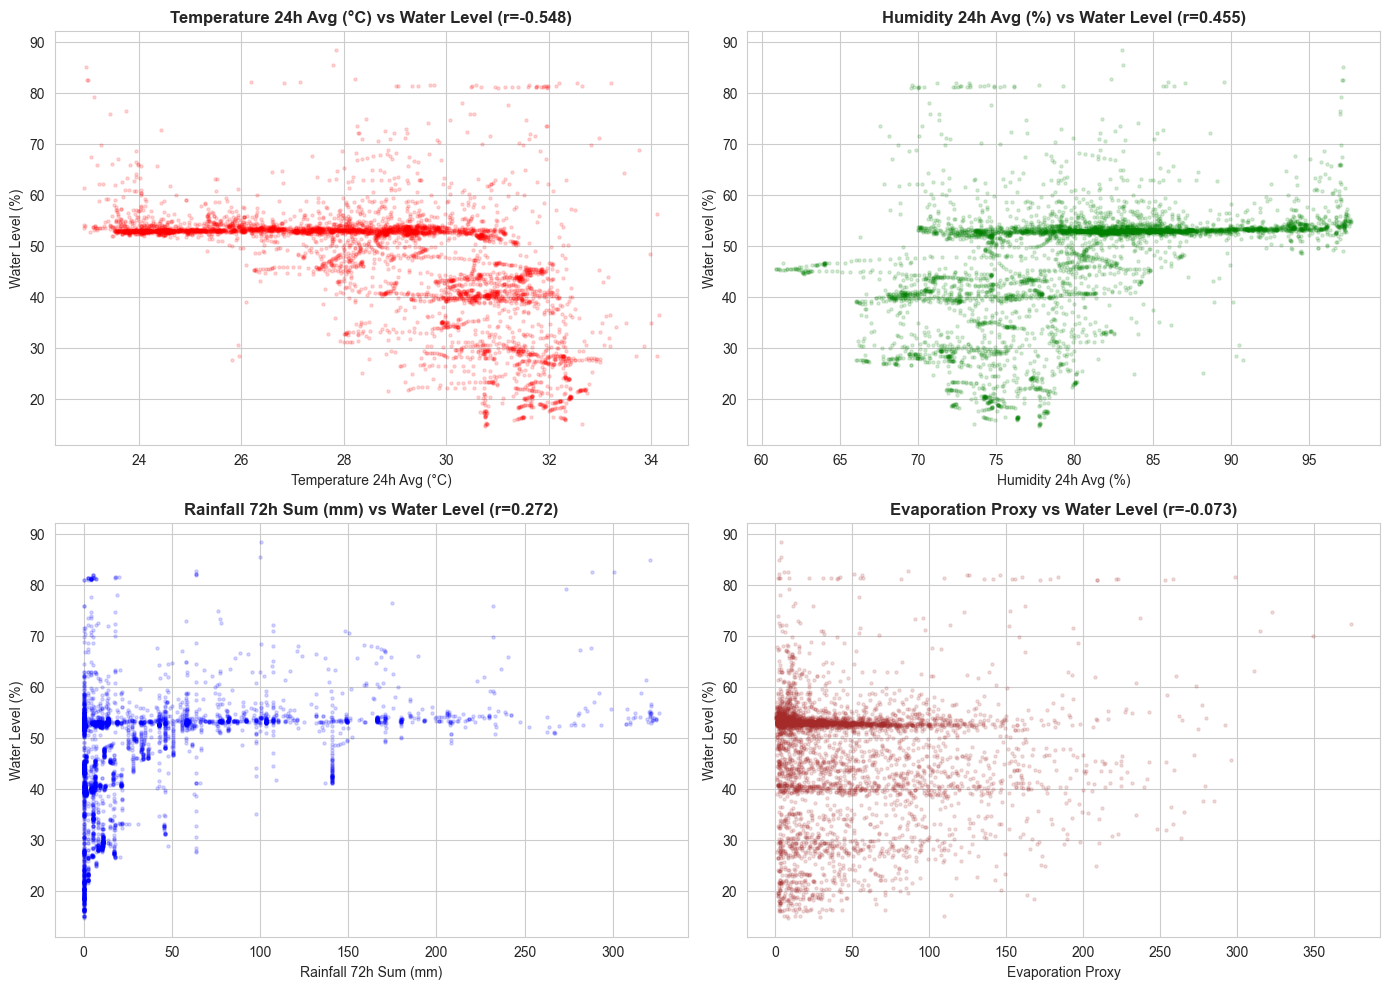

In [31]:
# SCATTER PLOTS — Key feature vs water level
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_pairs = [
    ('temp_avg_24h', 'Temperature 24h Avg (°C)', 'red'),
    ('hum_avg_24h', 'Humidity 24h Avg (%)', 'green'),
    ('rain_sum_72h', 'Rainfall 72h Sum (mm)', 'blue'),
    ('evap_proxy', 'Evaporation Proxy', 'brown')
]
for idx, (feat, label, color) in enumerate(scatter_pairs):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(merged_df[feat], merged_df['water_level_mean'], alpha=0.15, s=5, c=color)
    r = merged_df[feat].corr(merged_df['water_level_mean'])
    ax.set_xlabel(label)
    ax.set_ylabel('Water Level (%)')
    ax.set_title(f'{label} vs Water Level (r={r:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

DOMAIN-AWARE PATTERN ANALYSIS
merged_df not found in memory - loaded from preprocessed_water_level_data.csv
Tank emptying events (>5% drop/hour): 247
Rapid filling events (>3% rise/hour): 416

Monthly total rainfall:
  Month  1:     0.0 mm 
  Month  4:     0.0 mm 
  Month  5:    30.0 mm 
  Month  6:   206.4 mm #####
  Month  7:    30.0 mm 
  Month  8:   335.2 mm ########
  Month  9:   265.2 mm ######
  Month 10:   796.4 mm ####################
  Month 11:   265.6 mm ######
  Month 12:   326.4 mm ########


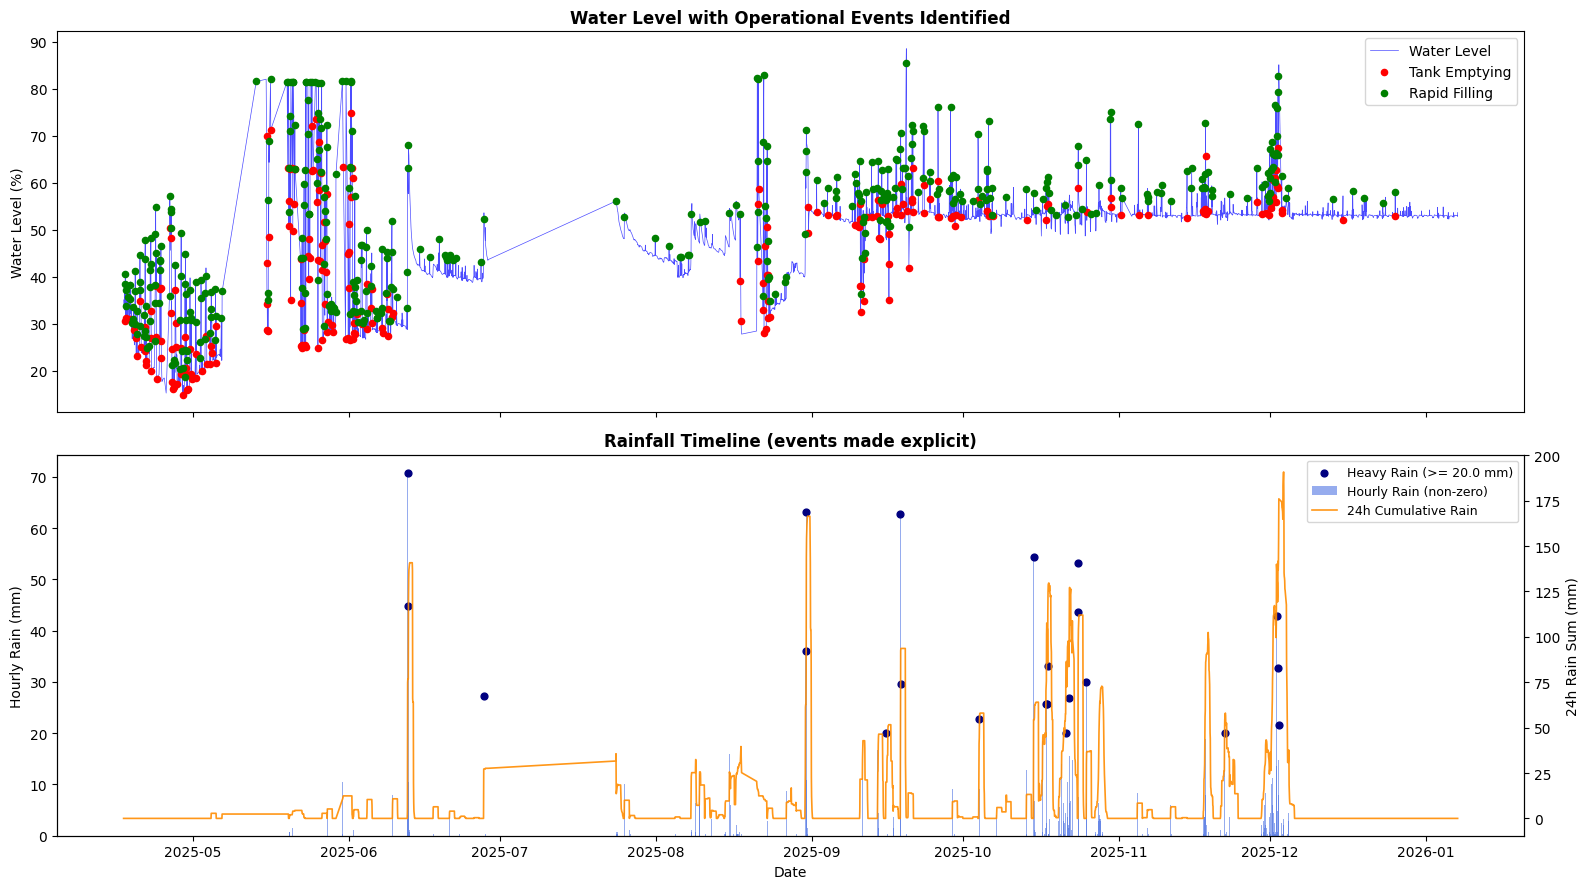


KEY INSIGHT: Sudden drops are TANK EMPTYING (pumps draining near-overflow tank)
  These are NOT anomalies - they are operational control actions.
  Rainfall is sparse in hourly data, so non-zero event highlighting improves interpretability.


In [3]:
# DOMAIN-AWARE PATTERN ANALYSIS
print("DOMAIN-AWARE PATTERN ANALYSIS")
print("=" * 50)

# Imports for standalone execution in a fresh kernel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fallback for fresh kernel: load latest preprocessed dataset if merged_df is missing
if 'merged_df' not in globals():
    merged_df = pd.read_csv('preprocessed_water_level_data.csv', index_col=0, parse_dates=True)
    print("merged_df not found in memory - loaded from preprocessed_water_level_data.csv")

# 1. Identify tank emptying events (sudden water level drops)
wl = merged_df['water_level_mean']
wl_change = wl.diff()

# Tank emptying = drop > 5% in 1 hour (operational pump action, not anomaly)
emptying_mask = wl_change < -5
filling_mask = wl_change > 3  # rapid filling from rain

print(f"Tank emptying events (>5% drop/hour): {emptying_mask.sum()}")
print(f"Rapid filling events (>3% rise/hour): {filling_mask.sum()}")

# 2. Rain seasonality
monthly_rain = merged_df.groupby(merged_df.index.month)['Rain'].sum()
print(f"\nMonthly total rainfall:")
for month, rain in monthly_rain.items():
    bar = "#" * int(rain / monthly_rain.max() * 20) if monthly_rain.max() > 0 else ""
    print(f"  Month {month:2d}: {rain:7.1f} mm {bar}")

# 3. Visualize emptying/filling patterns + rainfall visibility fix
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(merged_df.index, wl, color='blue', alpha=0.7, linewidth=0.5, label='Water Level')
axes[0].scatter(merged_df.index[emptying_mask], wl[emptying_mask], color='red', s=20, zorder=5, label='Tank Emptying')
axes[0].scatter(merged_df.index[filling_mask], wl[filling_mask], color='green', s=20, zorder=5, label='Rapid Filling')
axes[0].set_ylabel('Water Level (%)')
axes[0].set_title('Water Level with Operational Events Identified', fontweight='bold')
axes[0].legend()

# Rainfall timeline: plot only non-zero hourly rain so sparse events are visible
rain = merged_df['Rain'].fillna(0)
rain_nz = rain[rain > 0]
axes[1].bar(
    rain_nz.index, rain_nz.values,
    color='royalblue', alpha=0.55, width=0.08,
    label='Hourly Rain (non-zero)'
)

# Highlight heavy rain events (top 5%) for quick visual inspection
if len(rain_nz) > 0:
    heavy_thr = rain_nz.quantile(0.95)
    heavy = rain_nz[rain_nz >= heavy_thr]
    axes[1].scatter(heavy.index, heavy.values, color='navy', s=24, zorder=6,
                    label=f'Heavy Rain (>= {heavy_thr:.1f} mm)')

# Add 24h cumulative rain on secondary axis to show event build-up
ax_rain_cum = axes[1].twinx()
rain_24h = rain.rolling(24, min_periods=1).sum()
ax_rain_cum.plot(rain_24h.index, rain_24h.values, color='darkorange', linewidth=1.2, alpha=0.9,
                 label='24h Cumulative Rain')

axes[1].set_ylabel('Hourly Rain (mm)')
ax_rain_cum.set_ylabel('24h Rain Sum (mm)')
axes[1].set_title('Rainfall Timeline (events made explicit)', fontweight='bold')
axes[1].set_xlabel('Date')

# Merge legends from both axes
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax_rain_cum.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT: Sudden drops are TANK EMPTYING (pumps draining near-overflow tank)")
print("  These are NOT anomalies - they are operational control actions.")
print("  Rainfall is sparse in hourly data, so non-zero event highlighting improves interpretability.")

In [33]:
# DOMAIN-AWARE OUTLIER HANDLING
print("OUTLIER HANDLING - Domain-Aware Approach")
print("=" * 50)

# What is NOT an outlier (keeping these):
# - Rain events (sparse but real - the main signal for water level rise)
# - Tank emptying (sudden drops from pump operations)
# - High water levels during monsoon (normal seasonal behavior)
# - Low water levels during dry season (normal)

# What IS an outlier (sensor errors only):
# - Physically impossible values (water level < 0 or > 100%)
# - Temperature clearly wrong (e.g., > 60C or < -10C for this region)

n_before = len(merged_df)

# Keep track of operational events before filtering
drain_after_rain_before = int(merged_df['drain_after_rain_flag'].sum()) if 'drain_after_rain_flag' in merged_df.columns else 0
emptying_events_before = int((merged_df['wl_change_1h'] <= -5).sum()) if 'wl_change_1h' in merged_df.columns else 0

# Only remove truly impossible sensor readings
sensor_errors = (
    (merged_df['water_level_mean'] < 0) | (merged_df['water_level_mean'] > 100) |
    (merged_df['Temp_Out'] > 55) | (merged_df['Temp_Out'] < -5)
)
n_errors = int(sensor_errors.sum())
print(f"Physically impossible readings found: {n_errors}")

if n_errors > 0:
    merged_df = merged_df[~sensor_errors]
    print(f"Removed {n_errors} impossible sensor readings")

drain_after_rain_after = int(merged_df['drain_after_rain_flag'].sum()) if 'drain_after_rain_flag' in merged_df.columns else 0
emptying_events_after = int((merged_df['wl_change_1h'] <= -5).sum()) if 'wl_change_1h' in merged_df.columns else 0

print(f"Dataset: {n_before} -> {len(merged_df)} rows")
print(f"\nOperational drain-after-rain events retained: {drain_after_rain_after}/{drain_after_rain_before}")
print(f"Tank-emptying transitions retained: {emptying_events_after}/{emptying_events_before}")
print(f"\nNO data removed for:")
print(f"  - Rain events ({(merged_df['Rain'] > 0).sum()} rows with rain - these are signal, not noise)")
print("  - Tank emptying events (operational pattern, not anomaly)")
print("  - Extreme water levels (real seasonal variation)")

OUTLIER HANDLING - Domain-Aware Approach
Physically impossible readings found: 0
Dataset: 5141 -> 5141 rows

Operational drain-after-rain events retained: 113/113
Tank-emptying transitions retained: 247/247

NO data removed for:
  - Rain events (413 rows with rain - these are signal, not noise)
  - Tank emptying events (operational pattern, not anomaly)
  - Extreme water levels (real seasonal variation)


In [34]:
# FINAL DATA VERIFICATION
print("FINAL DATA VERIFICATION")
print("=" * 50)

# Check for any remaining NaN
nan_count = merged_df.isna().sum().sum()
print(f"NaN values: {nan_count}")
if nan_count > 0:
    merged_df = merged_df.ffill().bfill()
    print(f"After fill: {merged_df.isna().sum().sum()} NaN")

# Check for constant columns
const_cols = [col for col in merged_df.columns if merged_df[col].nunique() <= 1]
if const_cols:
    merged_df = merged_df.drop(columns=const_cols)
    print(f"Dropped constant columns: {const_cols}")

print(f"\nFinal dataset:")
print(f"  Shape: {merged_df.shape}")
print(f"  Date range: {merged_df.index.min()} to {merged_df.index.max()}")
print(f"  Target: water_level_mean [{merged_df['water_level_mean'].min():.1f}% - {merged_df['water_level_mean'].max():.1f}%]")
print(f"  Features: {len(merged_df.columns) - 1}")

FINAL DATA VERIFICATION
NaN values: 0

Final dataset:
  Shape: (5141, 40)
  Date range: 2025-04-17 05:00:00 to 2026-01-07 09:00:00
  Target: water_level_mean [14.8% - 88.5%]
  Features: 39


In [ ]:
# SAVE PREPROCESSED DATA — single clean file
merged_df.to_csv('preprocessed_water_level_data.csv')
print(f"Saved: preprocessed_water_level_data.csv")
print(f"  Shape: {merged_df.shape}")
print(f"  Features: {len(merged_df.columns) - 1}")
print(f"  Samples: {len(merged_df)}")

Saved: preprocessed_water_level_data.csv
  Shape: (5141, 40)
  Features: 39
  Samples: 5141

This is the ONLY file needed for model_water_level.ipynb
No separate scaler files — scaling will be done in model notebook as needed.
